# Coverage vs Cross-Verified
Compares the number of individuals per 50-year bin in Cultura and Cross-Verified, globally and by continent.

## Configuration

In [1]:
import tempfile
import duckdb
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from style import *

SEED = 42
DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'

ADULT_ONSET_OFFSET = 30
BIN_SIZE = 50
BIN_MIN = -1500
BIN_MAX_START = 1950
CONTINENTS = ['Europe', 'Asia', 'Africa', 'North America', 'Latin America', 'Middle East']
bins_50y = np.arange(BIN_MIN, BIN_MAX_START + 1, BIN_SIZE)

apply_style()

def format_year_label(year):
    return f'{abs(year)} BCE' if year < 0 else f'{year}'


## External data — Cross-Verified, citizenship aliases

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")
con.sql(f"ATTACH '{CROSS_VERIFIED_DB_PATH}' AS cv (READ_ONLY)")

con.sql("""
    CREATE TEMP TABLE cv_dates AS
    SELECT wikidata_code                      AS qid,
           citizenship_1_b,
           citizenship_2_b,
           birth                              AS birth_year,
           COALESCE(death, updated_death_date) AS death_year
    FROM   cv.individuals
""")

con.sql("""
    CREATE TEMP TABLE cv_years AS
    SELECT qid,
           citizenship_1_b,
           citizenship_2_b,
           CASE
               WHEN birth_year IS NOT NULL AND death_year IS NOT NULL
                   THEN CAST((birth_year + death_year) / 2 AS BIGINT)
               WHEN birth_year IS NOT NULL THEN birth_year + $offset
               WHEN death_year IS NOT NULL THEN death_year - $offset
           END AS year
    FROM   cv_dates
""", params={'offset': ADULT_ONSET_OFFSET})
print(con.sql('SELECT COUNT(*) AS rows, COUNT(year) AS with_year FROM cv_years').pl())
CV_CITIZENSHIP_ALIAS = {
    'US': 'United States', 'United_States': 'United States',
    'UK': 'United Kingdom', 'Great_Britain': 'United Kingdom',
    'Netherlands': 'Kingdom of the Netherlands',
    'China': "People's Republic of China", 'Hong_Kong': "People's Republic of China",
    'Czechoslovakia': 'Czech Republic', 'Yugoslavia': 'Serbia', 'Macedonia': 'North Macedonia',
    'East_Timor': 'Timor-Leste', 'Vatican': 'Vatican City', 'Burma': 'Myanmar',
    'Ivory_Coast': 'Ivory Coast', 'Gambia': 'The Gambia', 'Swaziland': 'Eswatini',
    'Dominican_republic': 'Dominican Republic', 'Congo_Republic': 'Republic of the Congo',
}

con.sql('SELECT * FROM cv_years LIMIT 5').pl()

shape: (1, 2)
┌─────────┬───────────┐
│ rows    ┆ with_year │
│ ---     ┆ ---       │
│ i64     ┆ i64       │
╞═════════╪═══════════╡
│ 2291817 ┆ 2141505   │
└─────────┴───────────┘


qid,citizenship_1_b,citizenship_2_b,year
str,str,str,i64
"""Q1000002""","""Germany""",null,1961
"""Q1000005""","""Czech_Republic""",null,1894
"""Q1000006""","""Germany""",null,2001
"""Q1000015""","""Germany""",null,2013
"""Q1000023""","""Germany""",null,1944


## Load Cultura data

### Effective year per individual

In [3]:
con.sql("""
    CREATE TEMP TABLE cultura_dates AS
    SELECT i.entity.qid                   AS qid,
           i.birth_date[1].year           AS birth_year,
           i.death_date[1].year           AS death_year,
           i.floruit_date[1].year         AS floruit_year,
           e.peak_productivity.start_year AS peak_start,
           e.peak_productivity.end_year   AS peak_end
    FROM      individual AS i
    LEFT JOIN individual_enriched AS e ON e.entity.qid = i.entity.qid
    WHERE     i.is_human
""")

con.sql("""
    CREATE TEMP TABLE cultura_years AS
    SELECT qid,
           COALESCE(
               CAST((birth_year + death_year) / 2 AS BIGINT),
               birth_year + $offset,
               death_year - $offset,
               floruit_year,
               CAST((peak_start + peak_end) / 2 AS BIGINT),
               peak_start,
               peak_end
           ) AS year
    FROM   cultura_dates
""", params={'offset': ADULT_ONSET_OFFSET})

cultura_year_stats = con.sql("""
    SELECT COUNT(*)            AS individuals,
           COUNT(year)         AS with_year,
           COUNT(DISTINCT qid) AS distinct_qid
    FROM   cultura_years
""").pl()
assert cultura_year_stats['individuals'][0] == cultura_year_stats['distinct_qid'][0]
print(f"with at least one date: {cultura_year_stats['with_year'][0]:,} / {cultura_year_stats['individuals'][0]:,}")
con.sql('SELECT * FROM cultura_years WHERE year IS NOT NULL LIMIT 5').pl()

with at least one date: 9,968,868 / 13,002,840


qid,year
str,i64
"""Q115837810""",1900
"""Q115837812""",1912
"""Q115837814""",1908
"""Q115837817""",1906
"""Q115837819""",1909


### Present-day state per individual

In [4]:
con.sql("""
    CREATE TEMP TABLE place_resolved_state AS
    SELECT    p.entity.qid AS place_qid,
              CASE WHEN p.present_day_state.name IS NOT NULL
                   THEN p.present_day_state
                   ELSE country.present_day_state
              END AS resolved_state
    FROM      place AS p
    LEFT JOIN place AS country ON country.entity.qid = p.country.qid
""")

con.sql("""
    CREATE TEMP TABLE place_state AS
    SELECT place_qid,
           resolved_state.name      AS state,
           resolved_state.continent AS continent
    FROM   place_resolved_state
    WHERE  resolved_state.name IS NOT NULL
""")

con.sql("""
    CREATE TEMP TABLE individual_place AS
    SELECT entity.qid                AS qid,
           place_of_birth.entity.qid AS place_qid
    FROM   individual
""")
con.sql("""
    INSERT INTO individual_place
    SELECT entity.qid, place_of_death.entity.qid
    FROM   individual
""")
con.sql("""
    INSERT INTO individual_place
    SELECT entity.qid, unnest(country_of_citizenship).entity.qid
    FROM   individual
""")

con.sql("""
    CREATE TEMP TABLE cultura_state AS
    SELECT DISTINCT ip.qid, ps.state
    FROM   individual_place AS ip
    JOIN   place_state AS ps USING (place_qid)
""")
print(con.sql('SELECT COUNT(*) AS places_with_state FROM place_state').pl())
print(con.sql('SELECT COUNT(*) AS pairs, COUNT(DISTINCT qid) AS individuals FROM cultura_state').pl())
con.sql('SELECT * FROM cultura_state LIMIT 5').pl()

shape: (1, 1)
┌───────────────────┐
│ places_with_state │
│ ---               │
│ i64               │
╞═══════════════════╡
│ 304876            │
└───────────────────┘
shape: (1, 2)
┌─────────┬─────────────┐
│ pairs   ┆ individuals │
│ ---     ┆ ---         │
│ i64     ┆ i64         │
╞═════════╪═════════════╡
│ 6993129 ┆ 6219380     │
└─────────┴─────────────┘


qid,state
str,str
"""Q1176640""","""United States"""
"""Q11768927""","""Poland"""
"""Q11774407""","""Czech Republic"""
"""Q115590732""","""North Macedonia"""
"""Q108919958""","""Czech Republic"""


## Preprocessing

### State → continent

In [5]:
state_continent_raw = con.sql('SELECT DISTINCT state, continent FROM place_state').pl()
assert state_continent_raw['state'].is_unique().all()
print(state_continent_raw.group_by('continent').len().sort('len', descending=True))
state_continent = state_continent_raw.filter(pl.col('continent').is_in(CONTINENTS))
state_to_continent = dict(state_continent.iter_rows())
con.register('state_continent', state_continent)
print(f'states: {state_continent_raw.height} → mapped to a continent: {state_continent.height}')
state_continent.group_by('continent').len().sort('len', descending=True)

shape: (11, 2)
┌───────────────┬─────┐
│ continent     ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ Africa        ┆ 61  │
│ Europe        ┆ 59  │
│ Asia          ┆ 35  │
│ Latin America ┆ 34  │
│ North America ┆ 21  │
│ …             ┆ …   │
│ Middle East   ┆ 17  │
│ Oceania       ┆ 11  │
│ null          ┆ 7   │
│ Antarctica    ┆ 5   │
│ South America ┆ 3   │
└───────────────┴─────┘
states: 271 → mapped to a continent: 227


continent,len
str,u32
"""Africa""",61
"""Europe""",59
"""Asia""",35
"""Latin America""",34
"""North America""",21
"""Middle East""",17


### Cross-Verified citizenship → continent

In [6]:
cv_tokens = con.sql("""
    SELECT citizenship_1_b AS citizenship FROM cv_years WHERE citizenship_1_b IS NOT NULL
    UNION
    SELECT citizenship_2_b AS citizenship FROM cv_years WHERE citizenship_2_b IS NOT NULL
""").pl()
cv_citizenship_continent = (
    cv_tokens
    .with_columns(pl.col('citizenship').map_elements(
        lambda c: state_to_continent.get(CV_CITIZENSHIP_ALIAS.get(c, c.replace('_', ' '))), return_dtype=pl.Utf8
    ).alias('continent'))
    .filter(pl.col('continent').is_not_null())
)
con.register('cv_citizenship_continent', cv_citizenship_continent)
print(f'CV citizenship values: {cv_tokens.height} → mapped: {cv_citizenship_continent.height}')
cv_citizenship_continent.head()

CV citizenship values: 245 → mapped: 188


citizenship,continent
str,str
"""Norway""","""Europe"""
"""Iran""","""Middle East"""
"""Hungary""","""Europe"""
"""Ecuador""","""Latin America"""
"""Argentina""","""Latin America"""


### Individual–continent–year

In [7]:
con.sql("""
    CREATE TEMP TABLE cv_continent AS
    SELECT DISTINCT y.qid, m.continent, y.year
    FROM   cv_years AS y
    JOIN   cv_citizenship_continent AS m ON m.citizenship IN (y.citizenship_1_b, y.citizenship_2_b)
    WHERE  y.year IS NOT NULL
""")
con.sql("""
    CREATE TEMP TABLE cultura_continent AS
    SELECT DISTINCT s.qid, m.continent, y.year
    FROM   cultura_state AS s
    JOIN   state_continent AS m USING (state)
    JOIN   cultura_years AS y USING (qid)
    WHERE  y.year IS NOT NULL
""")
n_before = con.sql('SELECT COUNT(*) FROM cultura_continent').fetchone()[0]
con.sql("""
    INSERT INTO cultura_continent
    SELECT qid, continent, year
    FROM   cv_continent
    WHERE  qid IN (SELECT qid FROM cultura_years)
    EXCEPT
    SELECT qid, continent, year
    FROM   cultura_continent
""")
n_after = con.sql('SELECT COUNT(*) FROM cultura_continent').fetchone()[0]
print(f'Cultura (qid, continent, year) rows: {n_before:,} → {n_after:,} after CV augmentation')
print(f"CV (qid, continent, year) rows: {con.sql('SELECT COUNT(*) FROM cv_continent').fetchone()[0]:,}")
con.sql('SELECT * FROM cultura_continent USING SAMPLE 5 ROWS (reservoir, 42)').pl()

Cultura (qid, continent, year) rows: 5,451,864 → 5,703,525 after CV augmentation
CV (qid, continent, year) rows: 2,059,060


qid,continent,year
str,str,i64
"""Q100591054""","""Europe""",1956
"""Q7000376""","""Europe""",1947
"""Q28325058""","""Europe""",2014
"""Q926715""","""Europe""",2001
"""Q130005400""","""Europe""",1968


### Counts per 50-year bin

In [8]:
def per_bin(table, group=None):
    group_column = f'{group}, ' if group else ''
    return con.sql(f"""
        SELECT   {group_column}CAST(floor(year / $bin_size) * $bin_size AS BIGINT) AS bin,
                 COUNT(*) AS n
        FROM     {table}
        WHERE    year IS NOT NULL
        GROUP BY {group_column}bin
        HAVING   bin BETWEEN $bin_min AND $bin_max
    """, params={'bin_size': BIN_SIZE, 'bin_min': BIN_MIN, 'bin_max': BIN_MAX_START}).pl()

def to_array(df):
    lookup = dict(zip(df['bin'].to_list(), df['n'].to_list()))
    return np.array([lookup.get(int(b), 0) for b in bins_50y])

cultura_per_bin = to_array(per_bin('cultura_years'))
cross_verified_per_bin = to_array(per_bin('cv_years'))
per_bin_global = pl.DataFrame({'bin': bins_50y, 'cultura': cultura_per_bin, 'cross_verified': cross_verified_per_bin})
assert cultura_per_bin.sum() <= cultura_year_stats['with_year'][0]
print(f'Cultura individuals in {BIN_MIN}–{BIN_MAX_START + BIN_SIZE - 1}: {cultura_per_bin.sum():,}; Cross-Verified: {cross_verified_per_bin.sum():,}')
per_bin_global.filter(pl.col('bin') >= 1700).head()

Cultura individuals in -1500–1999: 5,932,433; Cross-Verified: 1,634,728


bin,cultura,cross_verified
i64,i64,i64
1700,108918,21049
1750,170515,42887
1800,295719,79320
1850,585176,158515
1900,1330595,330284


In [9]:
cultura_bins_continent = per_bin('cultura_continent', 'continent')
cv_bins_continent = per_bin('cv_continent', 'continent')
continent_series = {
    c: {
        'cultura': to_array(cultura_bins_continent.filter(pl.col('continent') == c)),
        'cross_verified': to_array(cv_bins_continent.filter(pl.col('continent') == c)),
    }
    for c in CONTINENTS
}
continent_summary = pl.DataFrame([
    {'continent': c, 'cultura': int(s['cultura'].sum()), 'cross_verified': int(s['cross_verified'].sum())}
    for c, s in continent_series.items()
])
continent_summary

continent,cultura,cross_verified
str,i64,i64
"""Europe""",2716646,977498
"""Asia""",481234,92475
"""Africa""",70349,28535
"""North America""",604965,345176
"""Latin America""",188016,94924
"""Middle East""",120641,30073


## Figures

### Fig 1 — Global evolution

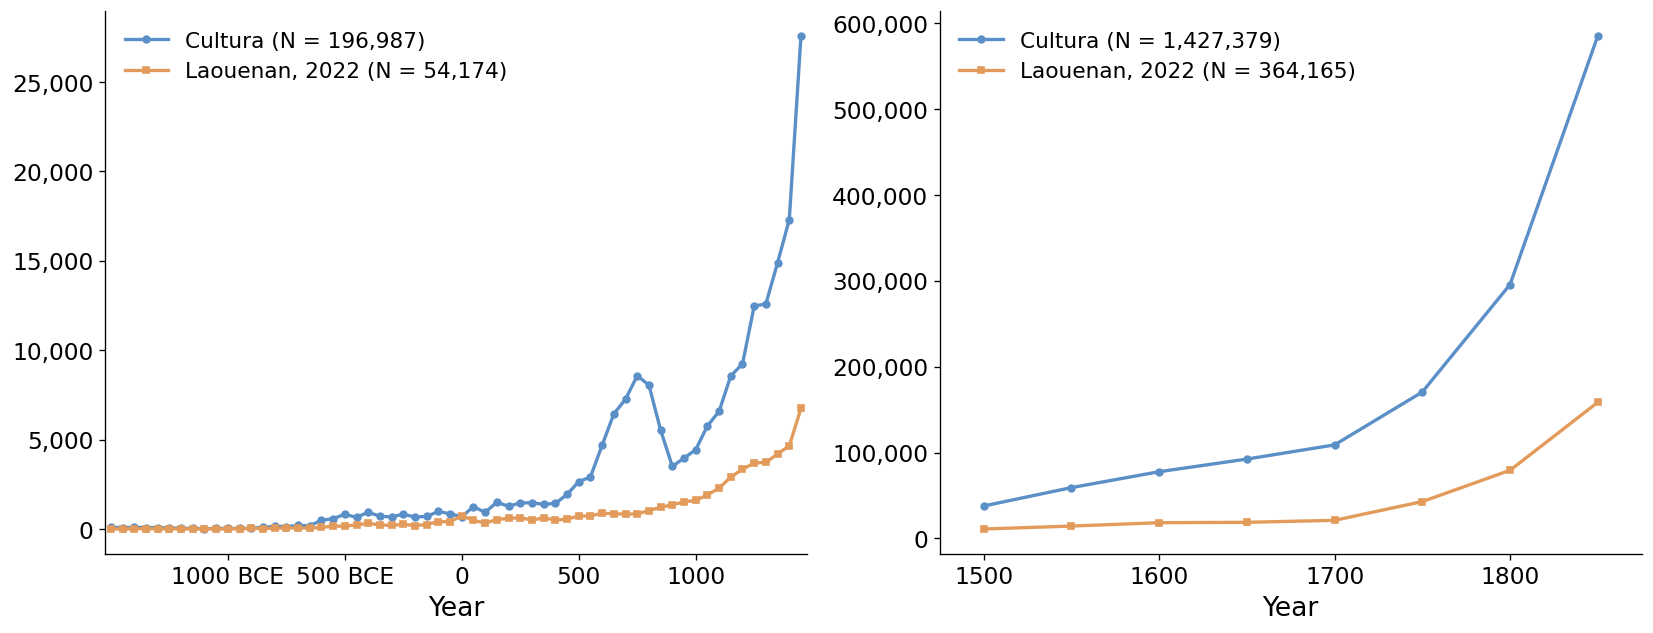

In [10]:
PRE_MODERN_BREAK = 1500
MODERN_END = 1900

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
masks = [bins_50y < PRE_MODERN_BREAK, (bins_50y >= PRE_MODERN_BREAK) & (bins_50y < MODERN_END)]
tick_sets = [np.arange(-1000, PRE_MODERN_BREAK, 500), np.arange(PRE_MODERN_BREAK, MODERN_END, 100)]
xlims = [(BIN_MIN - 25, PRE_MODERN_BREAK - 25), (PRE_MODERN_BREAK - 25, MODERN_END - 25)]

for ax, mask, ticks, xlim in zip(axes, masks, tick_sets, xlims):
    ax.plot(bins_50y[mask], cultura_per_bin[mask], color=DATABASE_COLORS['cultura'], marker='o', ms=4,
            label=f'Cultura (N = {int(cultura_per_bin[mask].sum()):,})')
    ax.plot(bins_50y[mask], cross_verified_per_bin[mask], color=DATABASE_COLORS['cross_verified'], marker='s', ms=4,
            label=f'Laouenan, 2022 (N = {int(cross_verified_per_bin[mask].sum()):,})')
    ax.set_xlim(*xlim)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in ticks])
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.set_xlabel('Year')
    ax.legend(loc='upper left')

fig.tight_layout()
plt.show()

### Fig 2 — Cultura vs Cross-Verified by continent

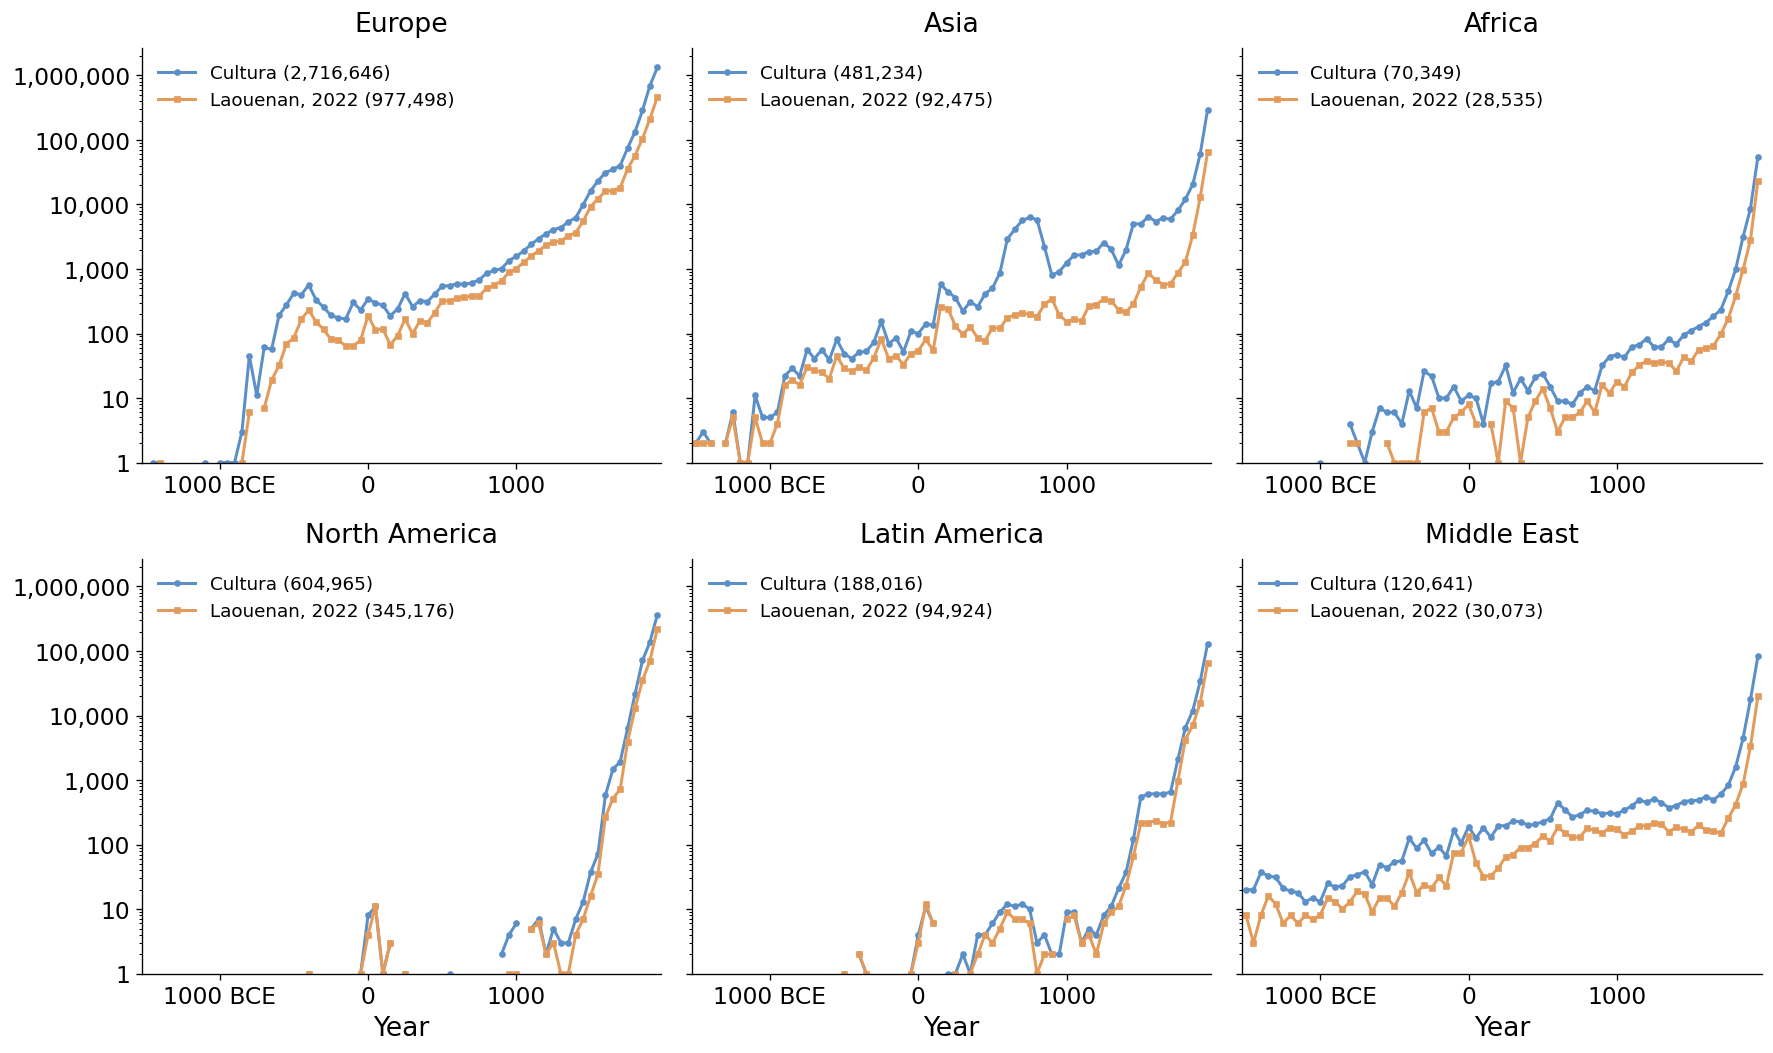

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
y_top = max(max(s['cultura'].max(), s['cross_verified'].max()) for s in continent_series.values()) * 2
ticks = np.arange(-1000, BIN_MAX_START + 1, 1000)

for ax, continent in zip(axes.flat, CONTINENTS):
    s = continent_series[continent]
    ax.plot(bins_50y, np.where(s['cultura'] > 0, s['cultura'], np.nan), color=DATABASE_COLORS['cultura'],
            lw=1.8, marker='o', ms=3, label=f"Cultura ({int(s['cultura'].sum()):,})")
    ax.plot(bins_50y, np.where(s['cross_verified'] > 0, s['cross_verified'], np.nan), color=DATABASE_COLORS['cross_verified'],
            lw=1.8, marker='s', ms=3, label=f"Laouenan, 2022 ({int(s['cross_verified'].sum()):,})")
    ax.set_yscale('log')
    ax.set_ylim(1, y_top)
    ax.set_xlim(BIN_MIN - 25, BIN_MAX_START + 25)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in ticks])
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.set_title(continent, pad=10)
    ax.legend(loc='upper left', fontsize=SMALL_LEGEND_FONTSIZE)

for ax in axes[-1, :]:
    ax.set_xlabel('Year')
fig.tight_layout()
plt.show()

### Fig 3 — Europe, Asia, Middle East (linear)

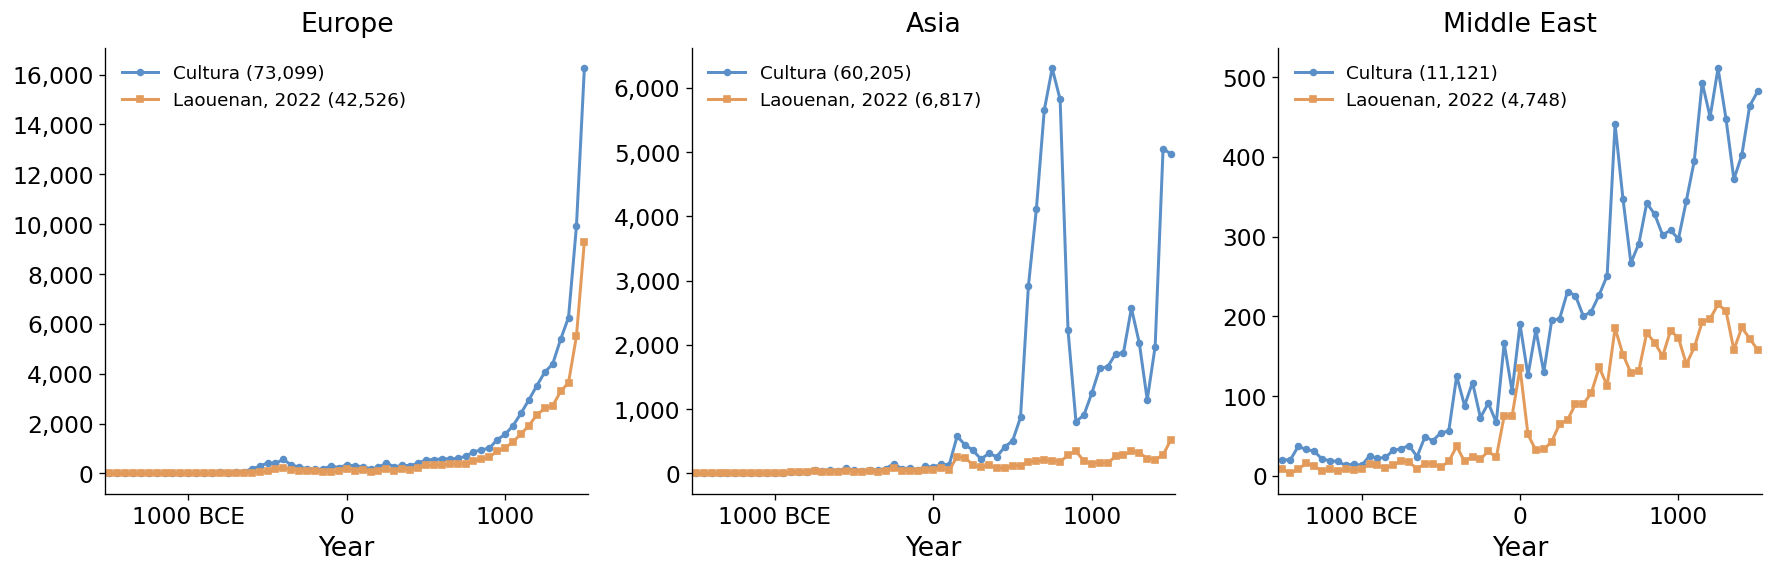

In [12]:
X_AXIS_END = 1500
FOCUS_CONTINENTS = ['Europe', 'Asia', 'Middle East']
keep = bins_50y <= X_AXIS_END
panel_ticks = np.arange(-1000, X_AXIS_END + 1, 1000)

fig, axes = plt.subplots(1, len(FOCUS_CONTINENTS), figsize=(15, 5))
for ax, continent in zip(axes, FOCUS_CONTINENTS):
    s = continent_series[continent]
    ax.plot(bins_50y[keep], s['cultura'][keep], color=DATABASE_COLORS['cultura'], lw=1.8, marker='o', ms=3.5,
            label=f"Cultura ({int(s['cultura'][keep].sum()):,})")
    ax.plot(bins_50y[keep], s['cross_verified'][keep], color=DATABASE_COLORS['cross_verified'], lw=1.8, marker='s', ms=3.5,
            label=f"Laouenan, 2022 ({int(s['cross_verified'][keep].sum()):,})")
    ax.set_xlim(BIN_MIN - 25, X_AXIS_END + 25)
    ax.set_xticks(panel_ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in panel_ticks])
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.set_title(continent, pad=10)
    ax.set_xlabel('Year')
    ax.legend(loc='upper left', fontsize=SMALL_LEGEND_FONTSIZE)

fig.tight_layout()
plt.show()

In [13]:
con.close()